# Titanic Machine Learning Notebook

This Jupyter Notebook follows the Titanic classification example from the slides. It includes detailed explanations and code cells for students to explore machine learning concepts.

## 🧭 Overview of the Titanic Dataset

The **Titanic dataset** is one of the most popular datasets for learning machine learning. It comes from the [Kaggle Titanic Competition](https://www.kaggle.com/c/titanic).

**Goal:** Predict passenger survival (0 = did not survive, 1 = survived).

**Main Columns:** `PassengerId`, `Survived`, `Pclass`, `Name`, `Sex`, `Age`, `SibSp`, `Parch`, `Fare`, `Embarked`

## ⚙️ Setting Up the Environment

We'll use **pandas**, **NumPy**, and **scikit-learn** for data analysis and modeling.

In [24]:
# %pip install pandas numpy scikit-learn seaborn matplotlib --quiet

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## 📂 Loading the Dataset

We'll use the Kaggle Titanic dataset files: `train.csv` and `test.csv`.

In [25]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 🔍 Exploring the Data

Let's inspect the structure, data types, and missing values.

In [26]:
train.info()
train.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


(891, 12)

## 📊 Descriptive Statistics

We can see summary statistics for numerical columns.

In [27]:
train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## 🧩 Handling Missing Values

We'll handle missing values for **Age** and **Embarked**, and drop **Cabin**.

In [28]:
train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [29]:
# Handle missing values - Updated for pandas 3.0 compatibility
train['Age'] = train['Age'].fillna(train['Age'].median())
train['Embarked'] = train['Embarked'].fillna(train['Embarked'].mode()[0])
train = train.drop('Cabin', axis=1)

train.isnull().sum()


PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

## 🧠 Feature Engineering

We'll create and encode new features to help the model learn better patterns.

### Convert Sex to Numeric

In [30]:
train['Sex'] = train['Sex'].map({'male': 0, 'female': 1})

### Encode Embarked using One-Hot Encoding

In [31]:
embarked_dummies = pd.get_dummies(train['Embarked'], prefix='Embarked')
train = pd.concat([train, embarked_dummies], axis=1)
train.drop('Embarked', axis=1, inplace=True)

### Create Family Size Feature

In [32]:
train['FamilySize'] = train['SibSp'] + train['Parch'] + 1

### Extract Title from Name

In [33]:
train['Title'] = train['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
train['Title'] = train['Title'].replace(['Mlle','Ms'],'Miss').replace('Mme','Mrs')
rare_titles = train['Title'].value_counts()[train['Title'].value_counts() < 10].index
train['Title'] = train['Title'].replace(rare_titles, 'Other')
train = pd.concat([train, pd.get_dummies(train['Title'], prefix='Title')], axis=1)
train.drop(['Name','Title'], axis=1, inplace=True)

## 📈 Visualization

Visualize relationships between features and survival.

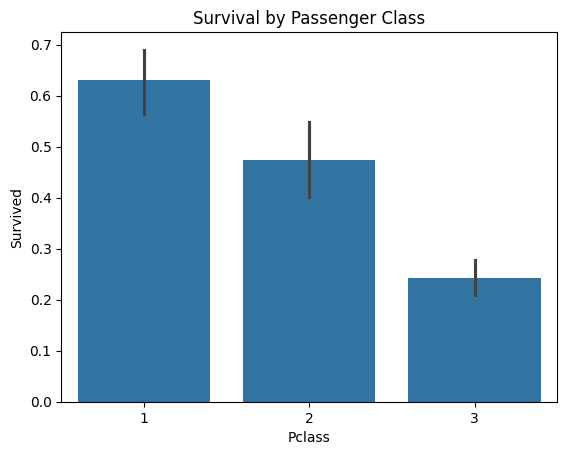

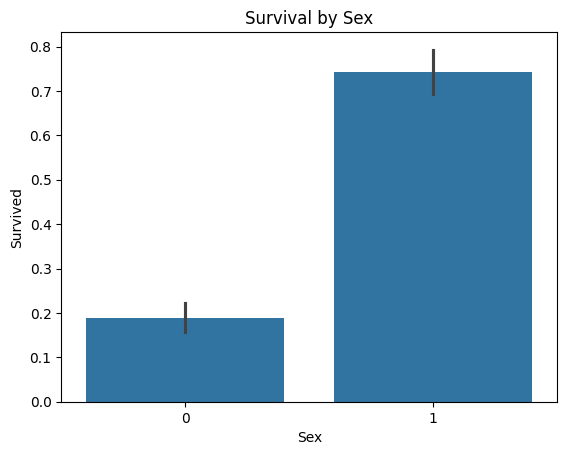

In [34]:
sns.barplot(x='Pclass', y='Survived', data=train)
plt.title('Survival by Passenger Class')
plt.show()

sns.barplot(x='Sex', y='Survived', data=train)
plt.title('Survival by Sex')
plt.show()

## 🔢 Correlation Heatmap

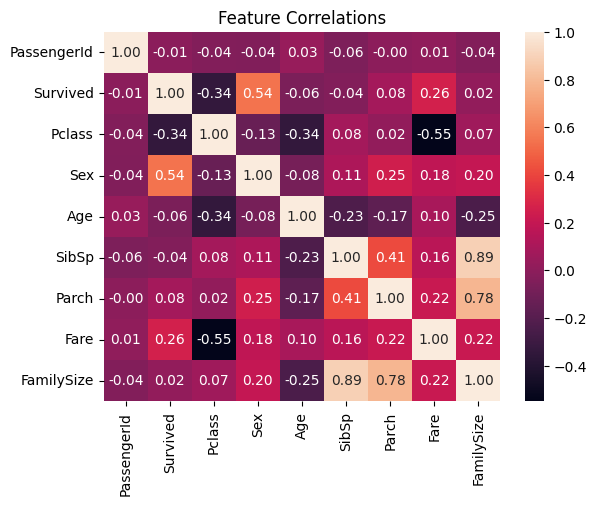

In [35]:
# Correlation Heatmap - only numeric columns
corr = train.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr, annot=True, fmt=".2f")
plt.title('Feature Correlations')
plt.show()

## 🧮 Preparing Data for Modeling

In [36]:
X = train.drop(['Survived', 'PassengerId', 'Ticket'], axis=1, errors='ignore')
y = train['Survived']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

## 🤖 Logistic Regression

In [37]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)
log_preds = log_model.predict(X_val)

print('Accuracy:', accuracy_score(y_val, log_preds))
print(classification_report(y_val, log_preds))

Accuracy: 0.8100558659217877
              precision    recall  f1-score   support

           0       0.84      0.84      0.84       105
           1       0.77      0.77      0.77        74

    accuracy                           0.81       179
   macro avg       0.80      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



## 🌳 Decision Tree Classifier

In [38]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
dt_preds = dt_model.predict(X_val)

print('Accuracy:', accuracy_score(y_val, dt_preds))
print(classification_report(y_val, dt_preds))

Accuracy: 0.776536312849162
              precision    recall  f1-score   support

           0       0.82      0.79      0.81       105
           1       0.72      0.76      0.74        74

    accuracy                           0.78       179
   macro avg       0.77      0.77      0.77       179
weighted avg       0.78      0.78      0.78       179



## 🌲 Random Forest Classifier

In [39]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_val)

print('Accuracy:', accuracy_score(y_val, rf_preds))

Accuracy: 0.8379888268156425


## 🧪 Cross-Validation

In [40]:
scores = cross_val_score(rf_model, X, y, cv=5)
print('Cross-validation scores:', scores)
print('Mean accuracy:', scores.mean())

Cross-validation scores: [0.79329609 0.79775281 0.84831461 0.75842697 0.81460674]
Mean accuracy: 0.8024794425961961


## 📊 Feature Importance

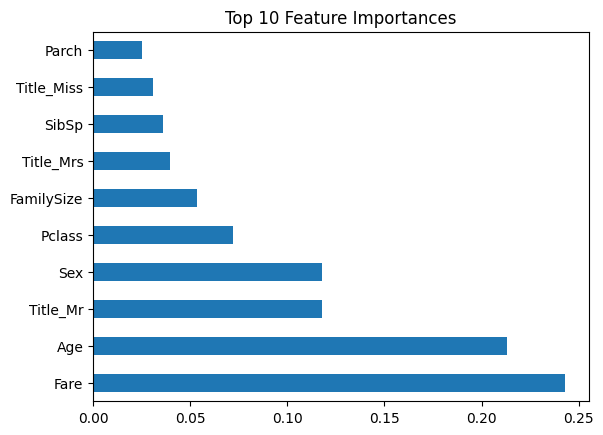

In [41]:
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
importances.nlargest(10).plot(kind='barh')
plt.title('Top 10 Feature Importances')
plt.show()

## 🚀 Predicting on Test Data (Optional)

Apply similar preprocessing to the test data and make predictions.

In [52]:
test_processed = test.copy()
# Apply similar preprocessing as above (left for student exercise)
# test_predictions = rf_model.predict(test_processed)

## 🧭 Ethical Considerations

Machine learning models can reflect biases in data. For example, survival may be correlated with gender or class — ensure fairness and avoid overfitting.

## 🌟 Next Steps

- Try tuning hyperparameters using GridSearchCV.
- Experiment with other algorithms like **XGBoost**.
- Apply to other datasets such as **Iris** or **Housing Prices**.

In [53]:
# ========================================
# INTERACTIVE SURVIVAL PREDICTOR
# ========================================
# Modify the values below to predict YOUR survival on the Titanic!

# YOUR INFORMATION (modify these values)
my_pclass = 3              # Passenger class: 1 (first), 2 (second), or 3 (third)
my_sex = 'male'            # Sex: 'male' or 'female'
my_age = 25                # Age in years
my_sibsp = 0               # Number of siblings/spouses aboard
my_parch = 0               # Number of parents/children aboard
my_fare = 7.25             # Fare paid (in British pounds)
my_embarked = 'S'          # Port of embarkation: 'C' (Cherbourg), 'Q' (Queenstown), 'S' (Southampton)
my_title = 'Mr'            # Title: 'Mr', 'Miss', 'Mrs', 'Master', or 'Other'

# ========================================
# BUILD YOUR PASSENGER PROFILE
# ========================================

# Create a dictionary with your information
my_data = {
    'Pclass': my_pclass,
    'Sex': 1 if my_sex.lower() == 'female' else 0,
    'Age': my_age,
    'SibSp': my_sibsp,
    'Parch': my_parch,
    'Fare': my_fare,
    'FamilySize': my_sibsp + my_parch + 1,
}

# Add Embarked one-hot encoding
my_data['Embarked_C'] = 1 if my_embarked == 'C' else 0
my_data['Embarked_Q'] = 1 if my_embarked == 'Q' else 0
my_data['Embarked_S'] = 1 if my_embarked == 'S' else 0

# Add Title one-hot encoding
my_data['Title_Master'] = 1 if my_title == 'Master' else 0
my_data['Title_Miss'] = 1 if my_title == 'Miss' else 0
my_data['Title_Mr'] = 1 if my_title == 'Mr' else 0
my_data['Title_Mrs'] = 1 if my_title == 'Mrs' else 0
my_data['Title_Other'] = 1 if my_title == 'Other' else 0

# Create DataFrame
my_passenger = pd.DataFrame([my_data])

# Ensure columns match training data
for col in X.columns:
    if col not in my_passenger.columns:
        my_passenger[col] = 0

my_passenger = my_passenger[X.columns]

# ========================================
# MAKE PREDICTION
# ========================================

# Predict survival
my_prediction = rf_model.predict(my_passenger)[0]
my_probability = rf_model.predict_proba(my_passenger)[0]

# Display results
print("="*50)
print("YOUR TITANIC SURVIVAL PREDICTION")
print("="*50)
print(f"\nPassenger Class: {my_pclass} ({'First' if my_pclass==1 else 'Second' if my_pclass==2 else 'Third'})")
print(f"Sex: {my_sex.capitalize()}")
print(f"Age: {my_age} years")
print(f"Title: {my_title}")
print(f"Family Size: {my_data['FamilySize']} (SibSp={my_sibsp}, Parch={my_parch})")
print(f"Fare: £{my_fare:.2f}")
print(f"Embarked: {my_embarked} ({'Cherbourg' if my_embarked=='C' else 'Queenstown' if my_embarked=='Q' else 'Southampton'})")

print("\n" + "="*50)
if my_prediction == 1:
    print("🎉 PREDICTION: YOU WOULD LIKELY SURVIVE! 🎉")
else:
    print("💀 PREDICTION: YOU WOULD LIKELY NOT SURVIVE 💀")

print("="*50)
print(f"\nSurvival Probability: {my_probability[1]:.1%}")
print(f"Death Probability: {my_probability[0]:.1%}")
print("\n" + "="*50)

YOUR TITANIC SURVIVAL PREDICTION

Passenger Class: 3 (Third)
Sex: Male
Age: 25 years
Title: Mr
Family Size: 1 (SibSp=0, Parch=0)
Fare: £7.25
Embarked: S (Southampton)

💀 PREDICTION: YOU WOULD LIKELY NOT SURVIVE 💀

Survival Probability: 8.0%
Death Probability: 92.0%

